<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/RVA_study71225.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
import numpy as np

In [87]:
df = pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [88]:
sheets = pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')
sheets.sheet_names

['raw data', 'data 1wk, 6wk and 3 months', 'sorted data']

In [89]:
sorted_data = sheets.parse('sorted data')
sorted_data.shape, sorted_data.columns

((172, 14),
 Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
        'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
        'Axis3mth'],
       dtype='object'))

In [90]:
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,41
Axis1wk,41
Sph6wk,1
Cyl6wk,3


In [91]:
# Drop rows with missing values in the 3-month follow-up columns
df1 = sorted_data.dropna(subset=['Sph3mth', 'Cyl3mth', 'Axis3mth'])


In [92]:
df1.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,23
Axis1wk,23
Sph6wk,0
Cyl6wk,0


In [93]:
df2 = df1.dropna(subset=['Sph1wk', 'Cyl1wk', 'Axis1wk'])
df2.isnull().sum()


,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,0
Cyl1wk,0
Axis1wk,0
Sph6wk,0
Cyl6wk,0


In [94]:
df2.shape, df2.columns

((87, 14),
 Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
        'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
        'Axis3mth'],
       dtype='object'))

In [95]:
df2.columns = df2.columns.str.strip()
df2.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

Preoperative Keratometry (R1, R2, A1 → M, J0, J45)

In [96]:
def keratometry_to_power_vectors(R1, R2, A1):
    C = R2 - R1  # cylinder in diopters
    M = (R1 + R2) / 2
    J0 = -0.5 * C * np.cos(np.deg2rad(2 * A1))
    J45 = -0.5 * C * np.sin(np.deg2rad(2 * A1))
    return M, J0, J45


In [97]:
df2[['M_preop', 'J0_preop', 'J45_preop']] = df2.apply(
    lambda row: keratometry_to_power_vectors(row['PreopR1'], row['PreopR2'], row['PreopA1']),
    axis=1, result_type='expand'
)


/tmp/ipython-input-1437736416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['M_preop', 'J0_preop', 'J45_preop']] = df2.apply(
/tmp/ipython-input-1437736416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['M_preop', 'J0_preop', 'J45_preop']] = df2.apply(
/tmp/ipython-input-1437736416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

In [98]:
df2

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,M_preop,J0_preop,J45_preop
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.50,-1.00,65.0,46.875,-0.241045,2.872667e-01
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.50,-2.00,80.0,47.375,0.587308,-2.137626e-01
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.50,-0.50,150.0,45.500,0.125000,2.165064e-01
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,80.0,1.75,-2.25,80.0,43.000,0.433013,-2.500000e-01
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,80.0,-0.50,-1.50,70.0,43.750,0.750000,-9.184851e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,90.0,-2.25,-3.25,120.0,47.125,-0.352385,-1.282576e-01
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,75.0,0.25,0.50,110.0,45.750,0.342020,-9.396926e-01
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,95.0,-2.00,-3.00,90.0,43.625,0.187500,-3.247595e-01
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,60.0,-0.50,-1.25,75.0,42.250,0.191511,1.606969e-01


In [99]:
def refraction_to_power_vectors(Sph, Cyl, Axis):
    M = Sph + Cyl / 2
    J0 = -0.5 * Cyl * np.cos(np.deg2rad(2 * Axis))
    J45 = -0.5 * Cyl * np.sin(np.deg2rad(2 * Axis))
    return M, J0, J45


In [100]:
# 1 week
df2[['M_1wk', 'J0_1wk', 'J45_1wk']] = df2.apply(
    lambda row: refraction_to_power_vectors(row['Sph1wk'], row['Cyl1wk'], row['Axis1wk']),
    axis=1, result_type='expand'
)

# 6 weeks
df2[['M_6wk', 'J0_6wk', 'J45_6wk']] = df2.apply(
    lambda row: refraction_to_power_vectors(row['Sph6wk'], row['Cyl6wk'], row['Axis6wk']),
    axis=1, result_type='expand'
)

# 3 months
df2[['M_3mth', 'J0_3mth', 'J45_3mth']] = df2.apply(
    lambda row: refraction_to_power_vectors(row['Sph3mth'], row['Cyl3mth'], row['Axis3mth']),
    axis=1, result_type='expand'
)


/tmp/ipython-input-3748521588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['M_1wk', 'J0_1wk', 'J45_1wk']] = df2.apply(
/tmp/ipython-input-3748521588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[['M_1wk', 'J0_1wk', 'J45_1wk']] = df2.apply(
/tmp/ipython-input-3748521588.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [101]:
df2

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,J45_preop,M_1wk,J0_1wk,J45_1wk,M_6wk,J0_6wk,J45_6wk,M_3mth,J0_3mth,J45_3mth
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,2.872667e-01,-0.500,-0.482091,-5.745333e-01,-0.375,-0.587308,-2.137626e-01,0.000,-0.321394,3.830222e-01
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,-2.137626e-01,-0.375,-1.057154,3.847727e-01,-0.250,-1.000000,1.224647e-16,-0.500,-0.939693,3.420201e-01
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,2.165064e-01,-1.250,0.383022,-3.213938e-01,-0.875,0.065118,-3.693029e-01,-0.750,0.125000,-2.165064e-01
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,-2.500000e-01,1.000,-1.000000,1.224647e-16,0.750,-0.939693,3.420201e-01,0.625,-1.057154,3.847727e-01
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-9.184851e-17,-1.250,-0.234923,-8.550504e-02,-1.625,-1.057154,3.847727e-01,-1.250,-0.574533,4.820907e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,-1.282576e-01,-4.000,-1.340578,1.124878e+00,-3.625,-1.625000,1.990051e-16,-3.875,-0.812500,-1.407291e+00
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,-9.396926e-01,1.250,0.086824,-4.924039e-01,0.750,0.216506,-1.250000e-01,0.500,0.191511,1.606969e-01
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,-3.247595e-01,-4.250,-0.750000,1.299038e+00,-4.000,-1.477212,-2.604723e-01,-3.500,-1.500000,1.836970e-16
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,1.606969e-01,-1.375,-0.615505,-1.085301e-01,-1.000,-0.250000,4.330127e-01,-1.125,-0.541266,3.125000e-01


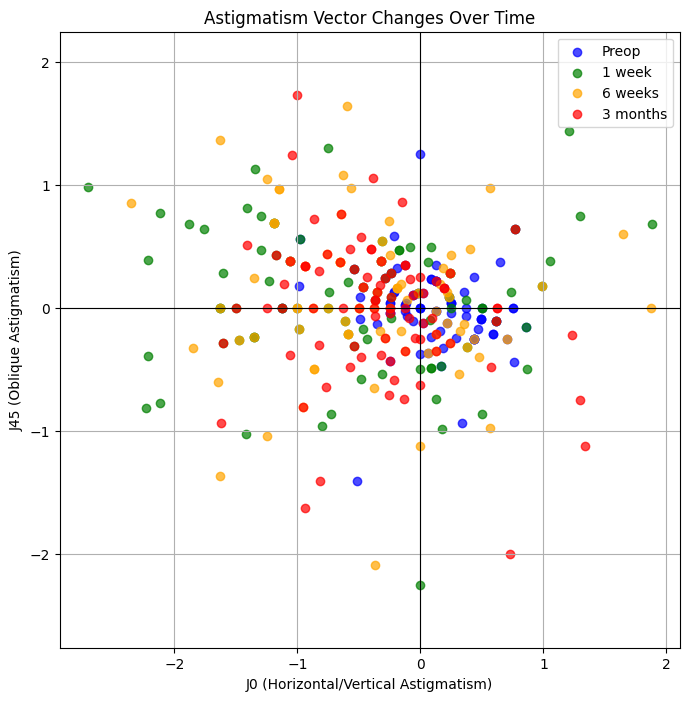

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# Preoperative
plt.scatter(df2['J0_preop'], df2['J45_preop'], color='blue', label='Preop', alpha=0.7)

# 1 week
plt.scatter(df2['J0_1wk'], df2['J45_1wk'], color='green', label='1 week', alpha=0.7)

# 6 weeks
plt.scatter(df2['J0_6wk'], df2['J45_6wk'], color='orange', label='6 weeks', alpha=0.7)

# 3 months
plt.scatter(df2['J0_3mth'], df2['J45_3mth'], color='red', label='3 months', alpha=0.7)

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('J0 (Horizontal/Vertical Astigmatism)')
plt.ylabel('J45 (Oblique Astigmatism)')
plt.title('Astigmatism Vector Changes Over Time')
plt.legend()
plt.grid(True)
plt.axis('equal')  # Equal scaling for x and y

plt.show()



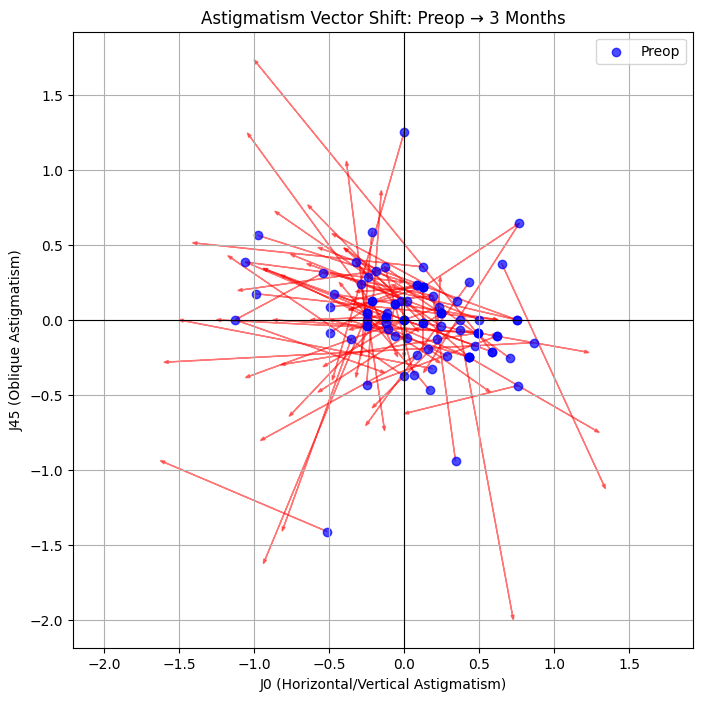

In [103]:
plt.figure(figsize=(8,8))

# Plot all patients: arrows from preop to 3 months
for i, row in df2.iterrows():
    plt.arrow(
        row['J0_preop'], row['J45_preop'],  # start at preop
        row['J0_3mth'] - row['J0_preop'],  # dx = postop - preop
        row['J45_3mth'] - row['J45_preop'],  # dy
        color='red', alpha=0.5, head_width=0.02, length_includes_head=True
    )

# Plot starting points (preop)
plt.scatter(df2['J0_preop'], df2['J45_preop'], color='blue', label='Preop', alpha=0.7)

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('J0 (Horizontal/Vertical Astigmatism)')
plt.ylabel('J45 (Oblique Astigmatism)')
plt.title('Astigmatism Vector Shift: Preop → 3 Months')
plt.legend()
plt.grid(True)
plt.axis('equal')

plt.show()


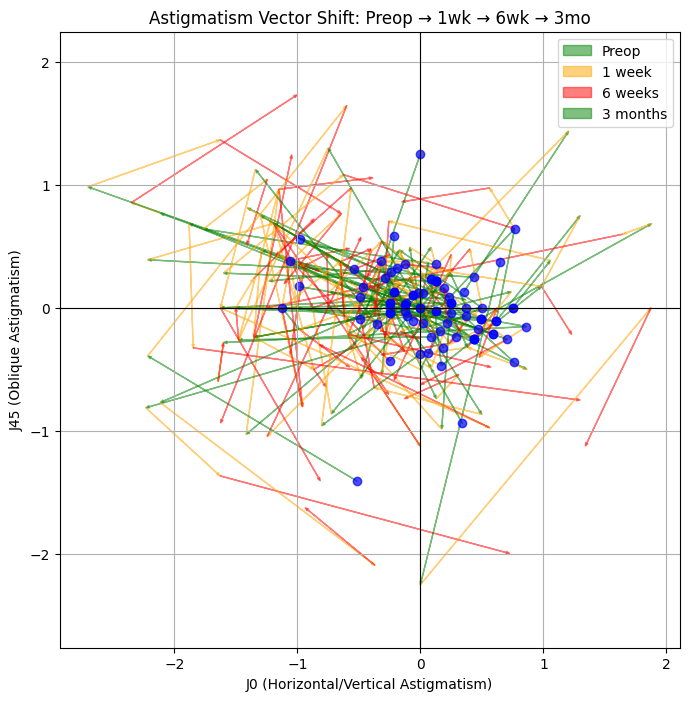

In [104]:
plt.figure(figsize=(8,8))

colors = ['green', 'orange', 'red']  # 1wk, 6wk, 3mth
time_points = ['J0_1wk', 'J0_6wk', 'J0_3mth']
time_points_J45 = ['J45_1wk', 'J45_6wk', 'J45_3mth']

for i, row in df2.iterrows():
    J0_prev, J45_prev = row['J0_preop'], row['J45_preop']  # start at preop
    for j, (tp, tp_j45) in enumerate(zip(time_points, time_points_J45)):
        J0_next, J45_next = row[tp], row[tp_j45]
        plt.arrow(
            J0_prev, J45_prev,
            J0_next - J0_prev,
            J45_next - J45_prev,
            color=colors[j], alpha=0.5, head_width=0.02, length_includes_head=True
        )
        J0_prev, J45_prev = J0_next, J45_next  # update start for next arrow

# Plot preop starting points
plt.scatter(df2['J0_preop'], df2['J45_preop'], color='blue', label='Preop', alpha=0.7)

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('J0 (Horizontal/Vertical Astigmatism)')
plt.ylabel('J45 (Oblique Astigmatism)')
plt.title('Astigmatism Vector Shift: Preop → 1wk → 6wk → 3mo')
plt.legend(['Preop', '1 week', '6 weeks', '3 months'])
plt.grid(True)
plt.axis('equal')

plt.show()


summary plot showing the magnitude of astigmatism for each patient at all time points. The magnitude is calculated as:
∣
J
∣
=
J
0
2
+
J
45
2
∣J∣=
J0
2
 +J45
2

​

This gives a single number representing total astigmatism, ignoring axis direction.

In [105]:
import numpy as np

time_points = ['preop', '1wk', '6wk', '3mth']

for tp in time_points:
    df2[f'J_mag_{tp}'] = np.sqrt(df2[f'J0_{tp}']**2 + df2[f'J45_{tp}']**2)


/tmp/ipython-input-246262483.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[f'J_mag_{tp}'] = np.sqrt(df2[f'J0_{tp}']**2 + df2[f'J45_{tp}']**2)
/tmp/ipython-input-246262483.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[f'J_mag_{tp}'] = np.sqrt(df2[f'J0_{tp}']**2 + df2[f'J45_{tp}']**2)
/tmp/ipython-input-246262483.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the d

/tmp/ipython-input-865596095.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Preop', '1 wk', '6 wk', '3 mo'], patch_artist=True,


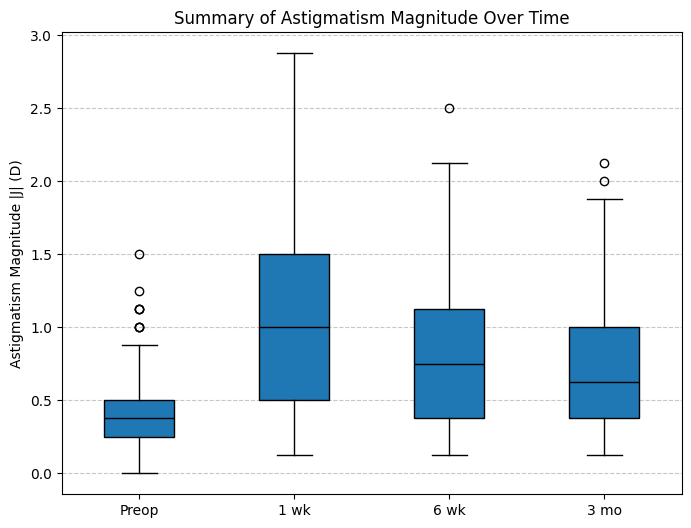

In [106]:
plt.figure(figsize=(8,6))

# Prepare data for boxplot
data = [df2[f'J_mag_{tp}'] for tp in time_points]

plt.boxplot(data, labels=['Preop', '1 wk', '6 wk', '3 mo'], patch_artist=True,
            medianprops=dict(color='black'))

plt.ylabel('Astigmatism Magnitude |J| (D)')
plt.title('Summary of Astigmatism Magnitude Over Time')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [107]:
from scipy.stats import skew, kurtosis, t
import numpy as np

summary_dict = {}
n = len(df2)  # sample size

for tp in ['preop', '1wk', '6wk', '3mth']:
    data = df2[f'J_mag_{tp}']
    mean_val = data.mean()
    std_val = data.std()
    median_val = data.median()
    min_val = data.min()
    max_val = data.max()
    skew_val = skew(data)
    kurt_val = kurtosis(data)  # excess kurtosis
    se = std_val / np.sqrt(n)  # standard error of the mean
    ci95 = se * t.ppf(0.975, n-1)  # 95% CI using t-distribution

    summary_dict[tp] = {
        'Mean': round(mean_val,2),
        'Std': round(std_val,2),
        'Median': round(median_val,2),
        'Min': round(min_val,2),
        'Max': round(max_val,2),
        'Skewness': round(skew_val,2),
        'Kurtosis': round(kurt_val,2),
        '95% CI': f"{round(mean_val - ci95,2)} - {round(mean_val + ci95,2)}"
    }

summary_table = pd.DataFrame(summary_dict)
summary_table



,preop,1wk,6wk,3mth
Mean,0.43,1.02,0.86,0.74
Std,0.3,0.63,0.56,0.49
Median,0.38,1.0,0.75,0.62
Min,0.0,0.12,0.12,0.12
Max,1.5,2.87,2.5,2.12
Skewness,1.23,0.72,0.82,0.92
Kurtosis,1.38,-0.29,-0.12,0.1
95% CI,0.37 - 0.5,0.89 - 1.16,0.74 - 0.98,0.63 - 0.85


In [108]:
import matplotlib.pyplot as plt

time_points = ['preop', '1wk', '6wk', '3mth']
means = []
ci_lower = []
ci_upper = []
n = len(df2)

for tp in time_points:
    data = df2[f'J_mag_{tp}']
    mean_val = data.mean()
    std_val = data.std()
    se = std_val / np.sqrt(n)
    ci95 = se * t.ppf(0.975, n-1)
    means.append(mean_val)
    ci_lower.append(mean_val - ci95)
    ci_upper.append(mean_val + ci95)


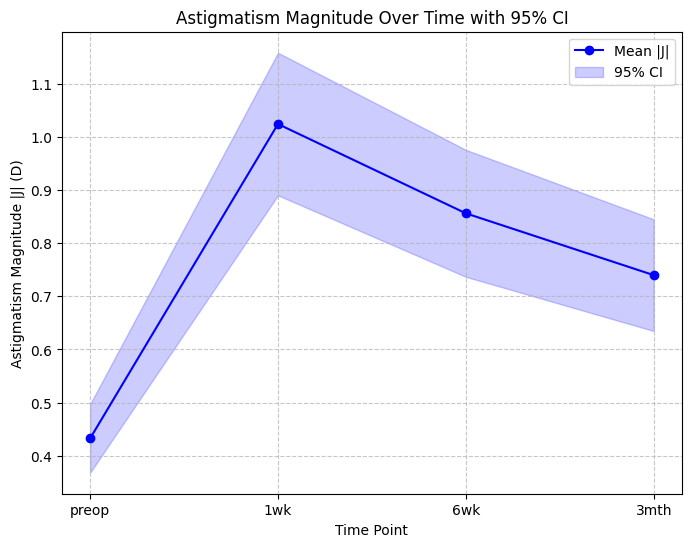

In [109]:
plt.figure(figsize=(8,6))

# Plot mean
plt.plot(time_points, means, marker='o', color='blue', label='Mean |J|')

# Fill 95% CI
plt.fill_between(time_points, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% CI')

plt.xlabel('Time Point')
plt.ylabel('Astigmatism Magnitude |J| (D)')
plt.title('Astigmatism Magnitude Over Time with 95% CI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [110]:
import matplotlib.pyplot as plt

time_points = ['Preop', '1 wk', '6 wk', '3 mo']
means = [0.43, 1.02, 0.86, 0.74]
ci_lower = [0.37, 0.89, 0.74, 0.63]
ci_upper = [0.50, 1.16, 0.98, 0.85]


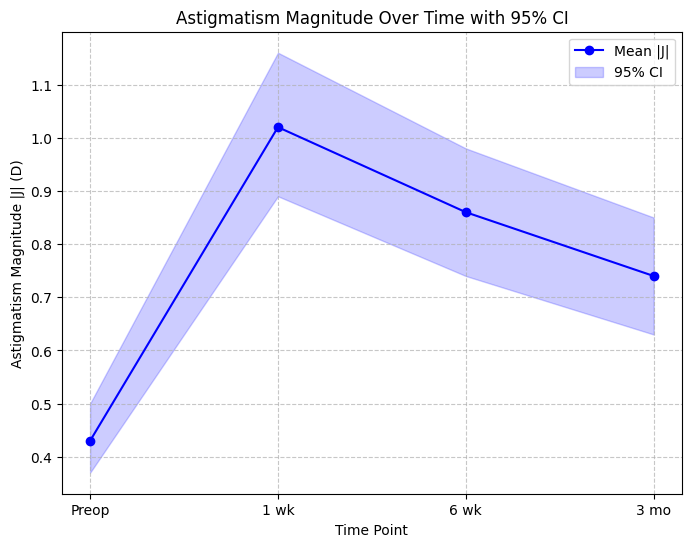

In [111]:
plt.figure(figsize=(8,6))

# Plot mean
plt.plot(time_points, means, marker='o', color='blue', label='Mean |J|')

# Fill 95% CI
plt.fill_between(time_points, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% CI')

plt.xlabel('Time Point')
plt.ylabel('Astigmatism Magnitude |J| (D)')
plt.title('Astigmatism Magnitude Over Time with 95% CI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [112]:
from scipy.stats import shapiro

# Preoperative astigmatism magnitude
preop_data = df2['J_mag_preop']

# Shapiro-Wilk test
stat, p_value = shapiro(preop_data)
print(f"Shapiro-Wilk Test: W = {stat:.3f}, p-value = {p_value:.3f}")



Shapiro-Wilk Test: W = 0.886, p-value = 0.000


In [113]:
from scipy.stats import shapiro
import pandas as pd

time_points = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
results = []

for tp in time_points:
    stat, p_value = shapiro(df2[tp])
    results.append({
        'Time Point': tp.replace('J_mag_', ''),
        'Shapiro-Wilk W': round(stat, 3),
        'p-value': round(p_value, 3),
        'Normality': 'Yes' if p_value > 0.05 else 'No'
    })

shapiro_table = pd.DataFrame(results)
shapiro_table


,Time Point,Shapiro-Wilk W,p-value,Normality
0,preop,0.886,0.0,No
1,1wk,0.925,0.0,No
2,6wk,0.917,0.0,No
3,3mth,0.907,0.0,No


In [114]:
import pandas as pd

time_points = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
summary_list = []

for tp in time_points:
    data = df2[tp]
    median_val = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    summary_list.append({
        'Time Point': tp.replace('J_mag_', ''),
        'Median': round(median_val, 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Min': round(data.min(), 2),
        'Max': round(data.max(), 2)
    })

median_iqr_table = pd.DataFrame(summary_list)
median_iqr_table


,Time Point,Median,Q1,Q3,IQR,Min,Max
0,preop,0.38,0.25,0.50,0.25,0.00,1.50
1,1wk,1.00,0.50,1.50,1.00,0.12,2.87
2,6wk,0.75,0.38,1.12,0.75,0.12,2.50
3,3mth,0.62,0.38,1.00,0.62,0.12,2.12


/tmp/ipython-input-1404944583.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, patch_artist=True,


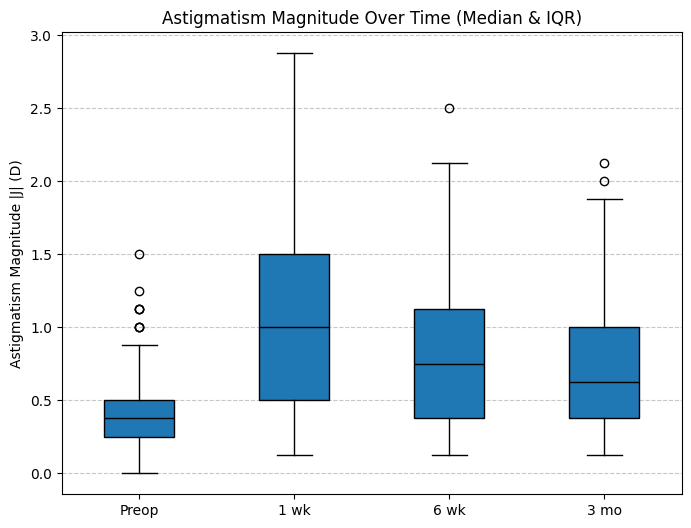

In [115]:
import matplotlib.pyplot as plt

time_points = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
labels = ['Preop', '1 wk', '6 wk', '3 mo']

# Prepare data
data_to_plot = [df2[tp] for tp in time_points]

plt.figure(figsize=(8,6))
plt.boxplot(data_to_plot, labels=labels, patch_artist=True,
            medianprops=dict(color='black'))

plt.ylabel('Astigmatism Magnitude |J| (D)')
plt.title('Astigmatism Magnitude Over Time (Median & IQR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [116]:
import matplotlib.pyplot as plt

time_points = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
labels = ['Preop', '1 wk', '6 wk', '3 mo']
data_to_plot = [df2[tp] for tp in time_points]


In [117]:
from scipy.stats import spearmanr

time_points = ['J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
correlations = []

for tp in time_points:
    corr, p_value = spearmanr(df2['J_mag_preop'], df2[tp])
    correlations.append({
        'Comparison': f'Preop vs {tp.replace("J_mag_","")}',
        'Spearman rho': round(corr, 3),
        'p-value': round(p_value, 3)
    })

spearman_table = pd.DataFrame(correlations)
spearman_table


,Comparison,Spearman rho,p-value
0,Preop vs 1wk,0.075,0.488
1,Preop vs 6wk,0.074,0.493
2,Preop vs 3mth,0.086,0.426


In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
cols = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
df_corr = df2[cols]


In [119]:
spearman_matrix = df_corr.corr(method='spearman')
spearman_matrix


,J_mag_preop,J_mag_1wk,J_mag_6wk,J_mag_3mth
J_mag_preop,1.000000,0.075367,0.074430,0.086391
J_mag_1wk,0.075367,1.000000,0.878263,0.830850
J_mag_6wk,0.074430,0.878263,1.000000,0.904819
J_mag_3mth,0.086391,0.830850,0.904819,1.000000


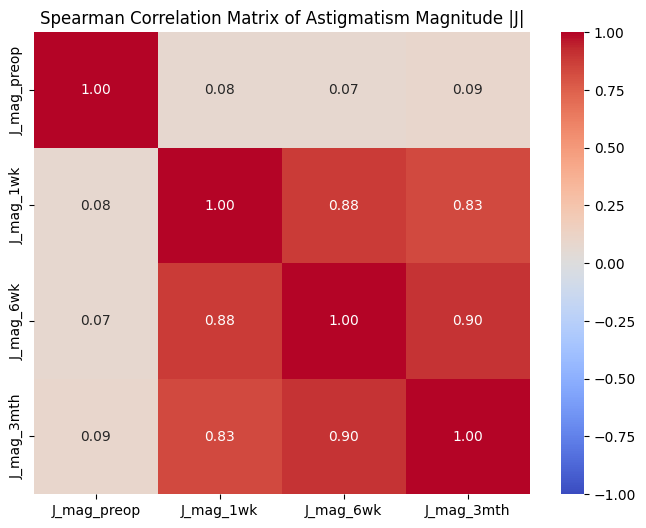

In [120]:
plt.figure(figsize=(8,6))
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix of Astigmatism Magnitude |J|')
plt.show()


In [121]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

cols = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']
df_corr = df2[cols]

# Initialize matrices
rho_matrix = pd.DataFrame(index=cols, columns=cols)
pval_matrix = pd.DataFrame(index=cols, columns=cols)

# Compute Spearman rho and p-values
for i in cols:
    for j in cols:
        rho, pval = spearmanr(df_corr[i], df_corr[j])
        rho_matrix.loc[i,j] = round(rho,2)
        pval_matrix.loc[i,j] = round(pval,3)


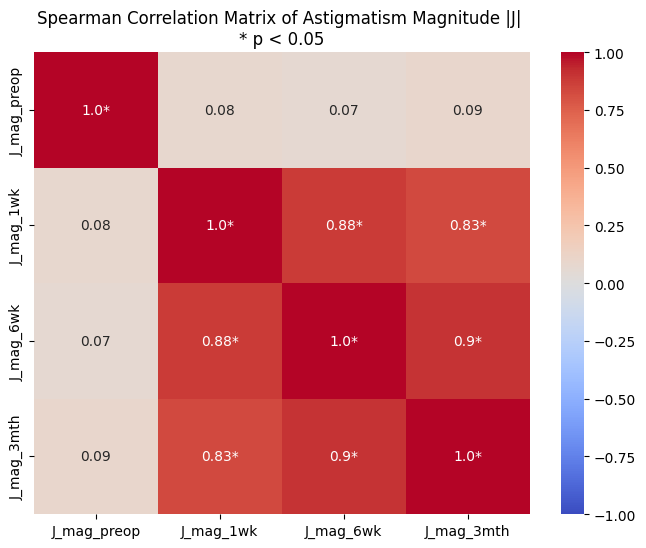

In [122]:
plt.figure(figsize=(8,6))

# Annotate with rho; add asterisks for significance
annot = rho_matrix.copy()
for i in cols:
    for j in cols:
        if pval_matrix.loc[i,j] < 0.05:
            annot.loc[i,j] = f"{annot.loc[i,j]}*"
        else:
            annot.loc[i,j] = f"{annot.loc[i,j]}"

sns.heatmap(rho_matrix.astype(float), annot=annot, fmt='', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix of Astigmatism Magnitude |J| \n* p < 0.05')
plt.show()


In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Time points
labels = ['Preop', '1wk', '6wk', '3mth']
cols = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']

# Summary stats for plotting
medians = [df2[col].median() for col in cols]
q1 = [df2[col].quantile(0.25) for col in cols]
q3 = [df2[col].quantile(0.75) for col in cols]

# Spearman correlations Preop vs each postop
rho_1wk, p_1wk = spearmanr(df2['J_mag_preop'], df2['J_mag_1wk'])
rho_6wk, p_6wk = spearmanr(df2['J_mag_preop'], df2['J_mag_6wk'])
rho_3mth, p_3mth = spearmanr(df2['J_mag_preop'], df2['J_mag_3mth'])


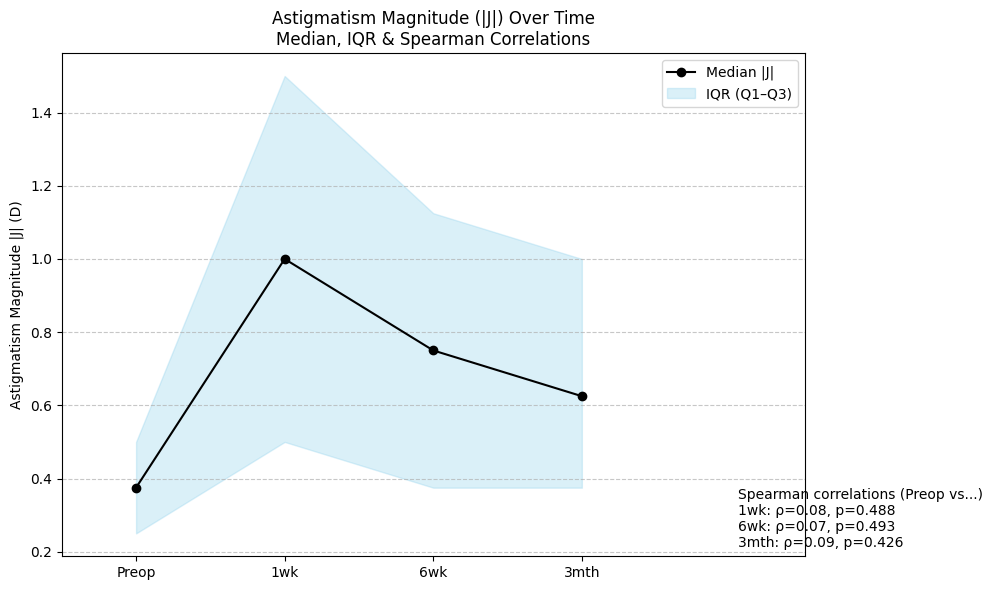

In [124]:
plt.figure(figsize=(10,6))

# Plot median line
plt.plot(labels, medians, marker='o', color='black', label='Median |J|')

# Shade IQR
plt.fill_between(labels, q1, q3, color='skyblue', alpha=0.3, label='IQR (Q1–Q3)')

plt.title('Astigmatism Magnitude (|J|) Over Time\nMedian, IQR & Spearman Correlations')
plt.ylabel('Astigmatism Magnitude |J| (D)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate Spearman correlations to the right of figure
plt.text(4.05, medians[0],
         f"Spearman correlations (Preop vs...)\n"
         f"1wk: ρ={rho_1wk:.2f}, p={p_1wk:.3f}\n"
         f"6wk: ρ={rho_6wk:.2f}, p={p_6wk:.3f}\n"
         f"3mth: ρ={rho_3mth:.2f}, p={p_3mth:.3f}",
         fontsize=10, va='top')

plt.xlim(-0.5, 4.5)
plt.legend()
plt.tight_layout()
plt.show()


In [125]:
import numpy as np

def cliffs_delta(x, y):
    """
    Computes Cliff's Delta for two independent or paired samples.
    δ = (number of x>y − number of x<y) / (n_x × n_y)
    """
    x = np.array(x)
    y = np.array(y)

    n_x = len(x)
    n_y = len(y)

    greater = 0
    lower = 0

    for i in x:
        for j in y:
            if i > j:
                greater += 1
            elif i < j:
                lower += 1

    delta = (greater - lower) / (n_x * n_y)
    return delta


In [126]:
delta_preop_1wk = cliffs_delta(df2['J_mag_preop'], df2['J_mag_1wk'])
delta_preop_6wk = cliffs_delta(df2['J_mag_preop'], df2['J_mag_6wk'])
delta_preop_3mth = cliffs_delta(df2['J_mag_preop'], df2['J_mag_3mth'])

effect_table = pd.DataFrame({
    'Comparison': ['Preop vs 1wk', 'Preop vs 6wk', 'Preop vs 3mth'],
    'Cliffs Delta (δ)': [delta_preop_1wk, delta_preop_6wk, delta_preop_3mth]
})
effect_table


,Comparison,Cliffs Delta (δ)
0,Preop vs 1wk,-0.624257
1,Preop vs 6wk,-0.502708
2,Preop vs 3mth,-0.394504


| Comparison    | Cliff’s Delta (δ) | Effect Size | Interpretation                             |
| ------------- | ----------------- | ----------- | ------------------------------------------ |
| Preop vs 1wk  | -0.624            | **Large**   | 1-week astigmatism > preop                 |
| Preop vs 6wk  | -0.503            | **Large**   | 6-week astigmatism > preop                 |
| Preop vs 3mth | -0.395            | **Medium**  | 3-month astigmatism > preop, but improving |


In [127]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

pairs = [
    ('J_mag_preop', 'J_mag_1wk'),
    ('J_mag_preop', 'J_mag_6wk'),
    ('J_mag_preop', 'J_mag_3mth')
]

wilcox_results = []

for a, b in pairs:
    stat, p = wilcoxon(df2[a], df2[b], zero_method='wilcox')
    wilcox_results.append({
        'Comparison': f"{a.replace('J_mag_', '')} vs {b.replace('J_mag_', '')}",
        'Wilcoxon W': stat,
        'p-value': round(p, 4)
    })

wilcox_table = pd.DataFrame(wilcox_results)
wilcox_table


,Comparison,Wilcoxon W,p-value
0,preop vs 1wk,327.5,0.0
1,preop vs 6wk,482.5,0.0
2,preop vs 3mth,661.0,0.0


In [128]:
def wilcoxon_effect_size(x, y):
    # Wilcoxon signed-rank test
    stat, p = wilcoxon(x, y, zero_method='wilcox')
    n = len(x)

    # Expected value and standard deviation
    mean_W = n*(n+1)/4
    sd_W = np.sqrt(n*(n+1)*(2*n+1)/24)

    # Compute Z
    z = (stat - mean_W) / sd_W

    # Effect size r
    r = z / np.sqrt(n)
    return z, r, p

effect_results = []

for a, b in pairs:
    z, r, p = wilcoxon_effect_size(df2[a], df2[b])
    effect_results.append({
        'Comparison': f"{a.replace('J_mag_', '')} vs {b.replace('J_mag_', '')}",
        'Z-value': round(z, 3),
        'Effect size r': round(abs(r), 3),
        'p-value': round(p, 4)
    })

effect_table = pd.DataFrame(effect_results)
effect_table


,Comparison,Z-value,Effect size r,p-value
0,preop vs 1wk,-6.715,0.720,0.0
1,preop vs 6wk,-6.059,0.650,0.0
2,preop vs 3mth,-5.303,0.569,0.0


In [129]:
from scipy.stats import friedmanchisquare

friedman_stat, friedman_p = friedmanchisquare(
    df2['J_mag_preop'],
    df2['J_mag_1wk'],
    df2['J_mag_6wk'],
    df2['J_mag_3mth']
)

friedman_stat, friedman_p


(np.float64(81.18455971049465), np.float64(1.7097302617246417e-17))

In [130]:
from scipy.stats import wilcoxon
import pandas as pd

comparisons = [
    ('J_mag_preop', 'J_mag_1wk'),
    ('J_mag_preop', 'J_mag_6wk'),
    ('J_mag_preop', 'J_mag_3mth'),
    ('J_mag_1wk', 'J_mag_6wk'),
    ('J_mag_1wk', 'J_mag_3mth'),
    ('J_mag_6wk', 'J_mag_3mth')
]

raw_p = []

for a, b in comparisons:
    stat, p = wilcoxon(df2[a], df2[b], zero_method='wilcox')
    raw_p.append(p)

# Holm correction
pvals = pd.Series(raw_p)
holm_p = pvals.rank(method="first")  # step index
holm_adj = pvals * (len(pvals) - holm_p + 1)
holm_adj = holm_adj.clip(upper=1)

posthoc_table = pd.DataFrame({
    'Comparison': [f"{a.replace('J_mag_','')} vs {b.replace('J_mag_','')}" for a,b in comparisons],
    'Raw p-value': raw_p,
    'Holm corrected p': holm_adj
})

posthoc_table


,Comparison,Raw p-value,Holm corrected p
0,preop vs 1wk,1.275980e-10,7.655883e-10
1,preop vs 6wk,2.860958e-08,1.144383e-07
2,preop vs 3mth,2.507584e-06,5.015168e-06
3,1wk vs 6wk,4.547228e-08,1.364168e-07
4,1wk vs 3mth,1.862743e-10,9.313715e-10
5,6wk vs 3mth,3.961547e-05,3.961547e-05


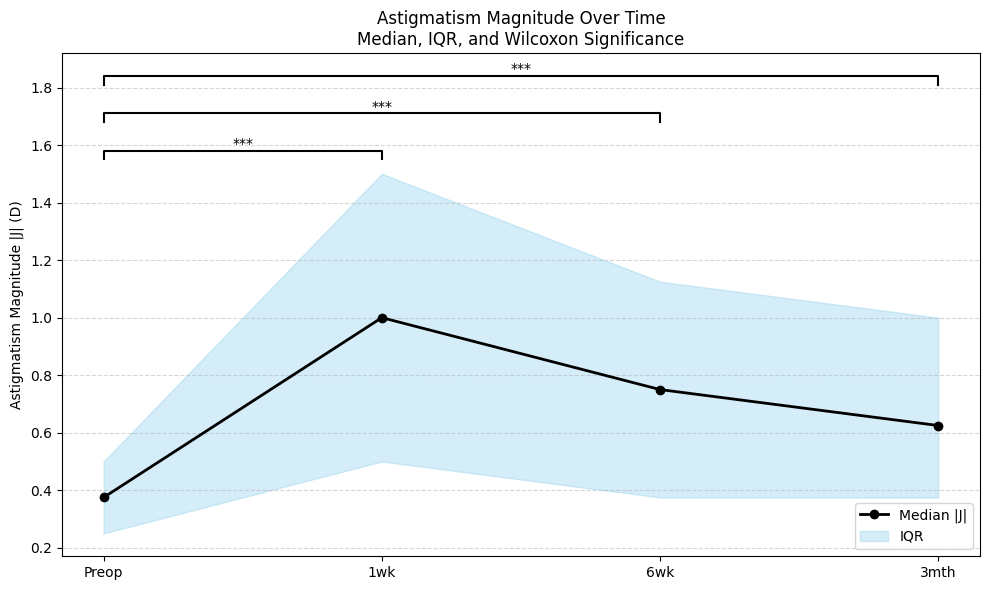

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# -------------------------
# 1. Compute medians & IQR
# -------------------------
labels = ['Preop', '1wk', '6wk', '3mth']
cols = ['J_mag_preop', 'J_mag_1wk', 'J_mag_6wk', 'J_mag_3mth']

medians = [df2[col].median() for col in cols]
q1 = [df2[col].quantile(0.25) for col in cols]
q3 = [df2[col].quantile(0.75) for col in cols]

# -------------------------
# 2. Pairwise Wilcoxon (with Holm correction)
# -------------------------
pairs = [
    ('J_mag_preop', 'J_mag_1wk'),
    ('J_mag_preop', 'J_mag_6wk'),
    ('J_mag_preop', 'J_mag_3mth')
]

raw_p = []
for a, b in pairs:
    _, p = wilcoxon(df2[a], df2[b], zero_method='wilcox')
    raw_p.append(p)

# Holm correction
pvals = pd.Series(raw_p)
ranks = pvals.rank(method="first")
holm_p = (pvals * (len(pvals) - ranks + 1)).clip(upper=1).tolist()

# For annotation
annotations = []
for p in holm_p:
    if p < 0.001:
        annotations.append("***")
    elif p < 0.01:
        annotations.append("**")
    elif p < 0.05:
        annotations.append("*")
    else:
        annotations.append("ns")

# -------------------------
# 3. Plot
# -------------------------
plt.figure(figsize=(10,6))

# Median line
plt.plot(labels, medians, marker='o', color='black', label='Median |J|', linewidth=2)

# IQR shading
plt.fill_between(labels, q1, q3, color='skyblue', alpha=0.35, label='IQR')

plt.ylabel("Astigmatism Magnitude |J| (D)")
plt.title("Astigmatism Magnitude Over Time\nMedian, IQR, and Wilcoxon Significance")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# -------------------------
# 4. Add significance annotations
# -------------------------
# Preop vs 1wk
x1, x2 = 0, 1
y = max(q3) + 0.05
plt.plot([x1, x1, x2, x2], [y, y+0.03, y+0.03, y], color='black')
plt.text((x1+x2)/2, y+0.04, annotations[0], ha='center')

# Preop vs 6wk
x1, x2 = 0, 2
y = max(q3) + 0.18
plt.plot([x1, x1, x2, x2], [y, y+0.03, y+0.03, y], color='black')
plt.text((x1+x2)/2, y+0.04, annotations[1], ha='center')

# Preop vs 3mth
x1, x2 = 0, 3
y = max(q3) + 0.31
plt.plot([x1, x1, x2, x2], [y, y+0.03, y+0.03, y], color='black')
plt.text((x1+x2)/2, y+0.04, annotations[2], ha='center')

plt.legend()
plt.tight_layout()
plt.show()


In [132]:
import statsmodels.api as sm
import pandas as pd

# Predictor variables
X = df2[['PreopR1', 'PreopR2', 'PreopA1', 'J_mag_1wk']]

# Dependent variable
y = df2['J_mag_3mth']

# Add constant for intercept
X = sm.add_constant(X)

# Build model
model = sm.OLS(y, X).fit()

# View summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             J_mag_3mth   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.661
Method:                 Least Squares   F-statistic:                     42.90
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           2.26e-19
Time:                        18:05:54   Log-Likelihood:                -12.389
No. Observations:                  87   AIC:                             34.78
Df Residuals:                      82   BIC:                             47.11
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8312      0.893      0.931      0.3

In [133]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data


,feature,VIF
0,const,839.668557
1,PreopR1,7.535401
2,PreopR2,7.518837
3,PreopA1,1.071746
4,J_mag_1wk,1.062976


<Figure size 600x400 with 0 Axes>

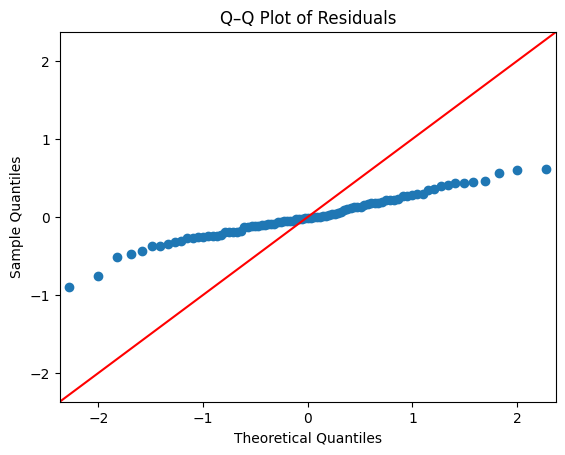

In [134]:
import matplotlib.pyplot as plt
import scipy.stats as stats

resid = model.resid

plt.figure(figsize=(6,4))
sm.qqplot(resid, line='45')
plt.title("Q–Q Plot of Residuals")
plt.show()


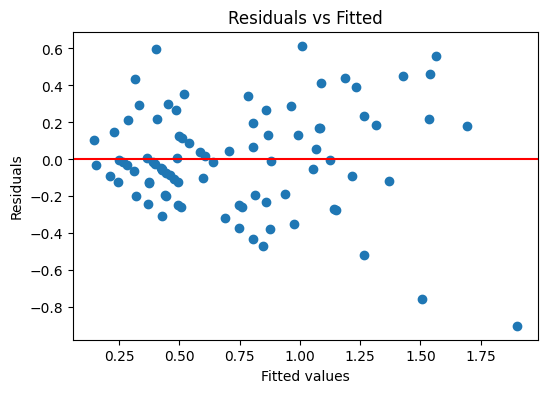

In [135]:
fitted = model.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(fitted, resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


In [136]:
import numpy as np

mae = np.mean(np.abs(resid))
rmse = np.sqrt(np.mean(resid**2))

mae, rmse


(np.float64(0.21463319371172745), np.float64(0.27900088071667095))

/tmp/ipython-input-2495265486.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_fit = model_simple.params[0] + model_simple.params[1]*x_fit
/tmp/ipython-input-2495265486.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'OLS fit: y={model_simple.params[1]:.2f}x+{model_simple.params[0]:.2f}')


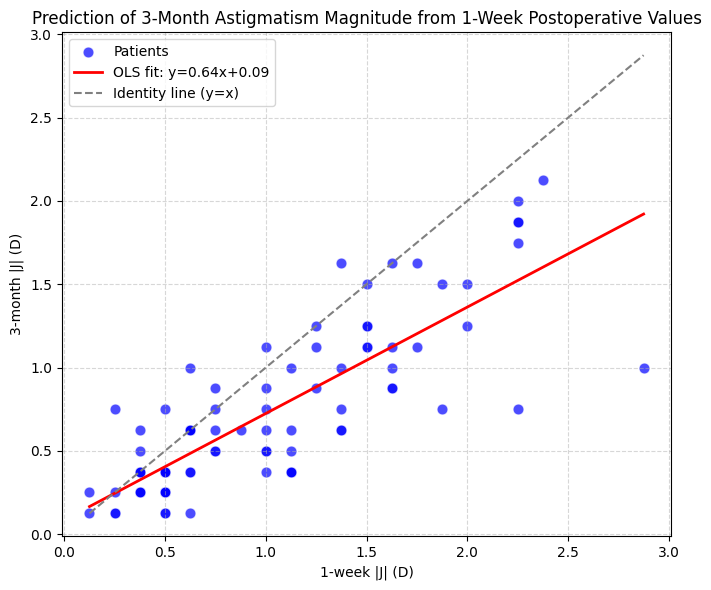

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# Variables
x = df2['J_mag_1wk']
y = df2['J_mag_3mth']

# Fit simple OLS for plotting (3mth ~ 1wk)
X = sm.add_constant(x)
model_simple = sm.OLS(y, X).fit()

# Regression line
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = model_simple.params[0] + model_simple.params[1]*x_fit

# Plot
plt.figure(figsize=(7,6))
sns.scatterplot(x=x, y=y, color='blue', s=60, alpha=0.7, label='Patients')
plt.plot(x_fit, y_fit, color='red', linewidth=2, label=f'OLS fit: y={model_simple.params[1]:.2f}x+{model_simple.params[0]:.2f}')
plt.plot(x_fit, x_fit, color='gray', linestyle='--', label='Identity line (y=x)')

plt.xlabel("1-week |J| (D)")
plt.ylabel("3-month |J| (D)")
plt.title("Prediction of 3-Month Astigmatism Magnitude from 1-Week Postoperative Values")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
